# **1. Perkenalan Dataset**

# Deskripsi Dataset

Dataset yang digunakan adalah **Raisin Dataset** yang berasal dari **Kaggle** dan juga tersedia di **UCI Machine Learning Repository**.

Dataset ini digunakan untuk melakukan klasifikasi dua jenis kismis, yaitu:

* Kecimen
* Besni

## Informasi Dataset

Dataset memiliki:

* 900 data
* 7 fitur numerik
* 1 target class

## Fitur Dataset

Fitur yang digunakan pada dataset meliputi:

* Area
* MajorAxisLength
* MinorAxisLength
* Eccentricity
* ConvexArea
* Extent
* Perimeter

## Target

Target pada dataset adalah:

* `Class`

Target ini berisi label jenis kismis:

* `Kecimen`
* `Besni`

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# **3. Memuat Dataset**

In [2]:
# Load dataset
df = pd.read_excel('/kaggle/input/datasets/muratkokludataset/raisin-dataset/Raisin_Dataset/Raisin_Dataset.xlsx')

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [3]:
print("Shape Dataset :", df.shape)
df.info()

Shape Dataset : (900, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [4]:
df.dtypes

Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
Eccentricity       float64
ConvexArea           int64
Extent             float64
Perimeter          float64
Class               object
dtype: object

In [5]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


# **4. Exploratory Data Analysis (EDA)**

In [6]:
df.isnull().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

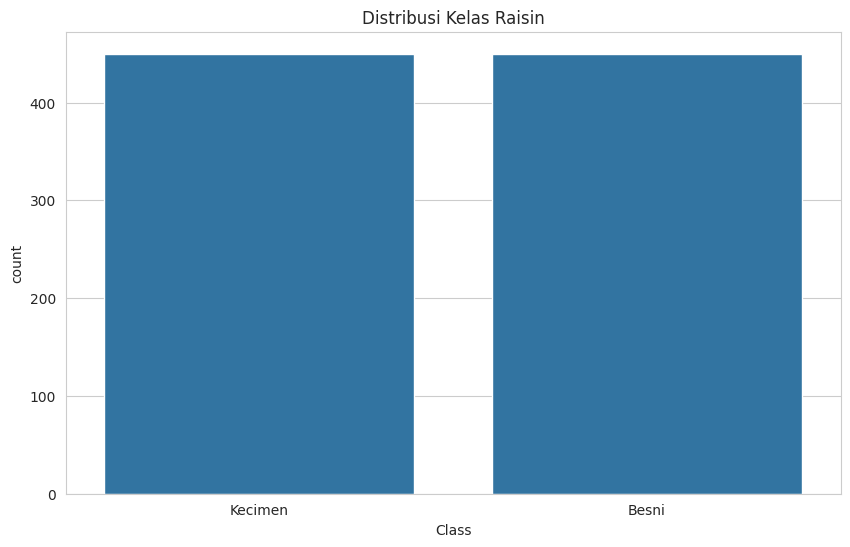

In [8]:
sns.countplot(x='Class', data=df)

plt.title('Distribusi Kelas Raisin')
plt.show()

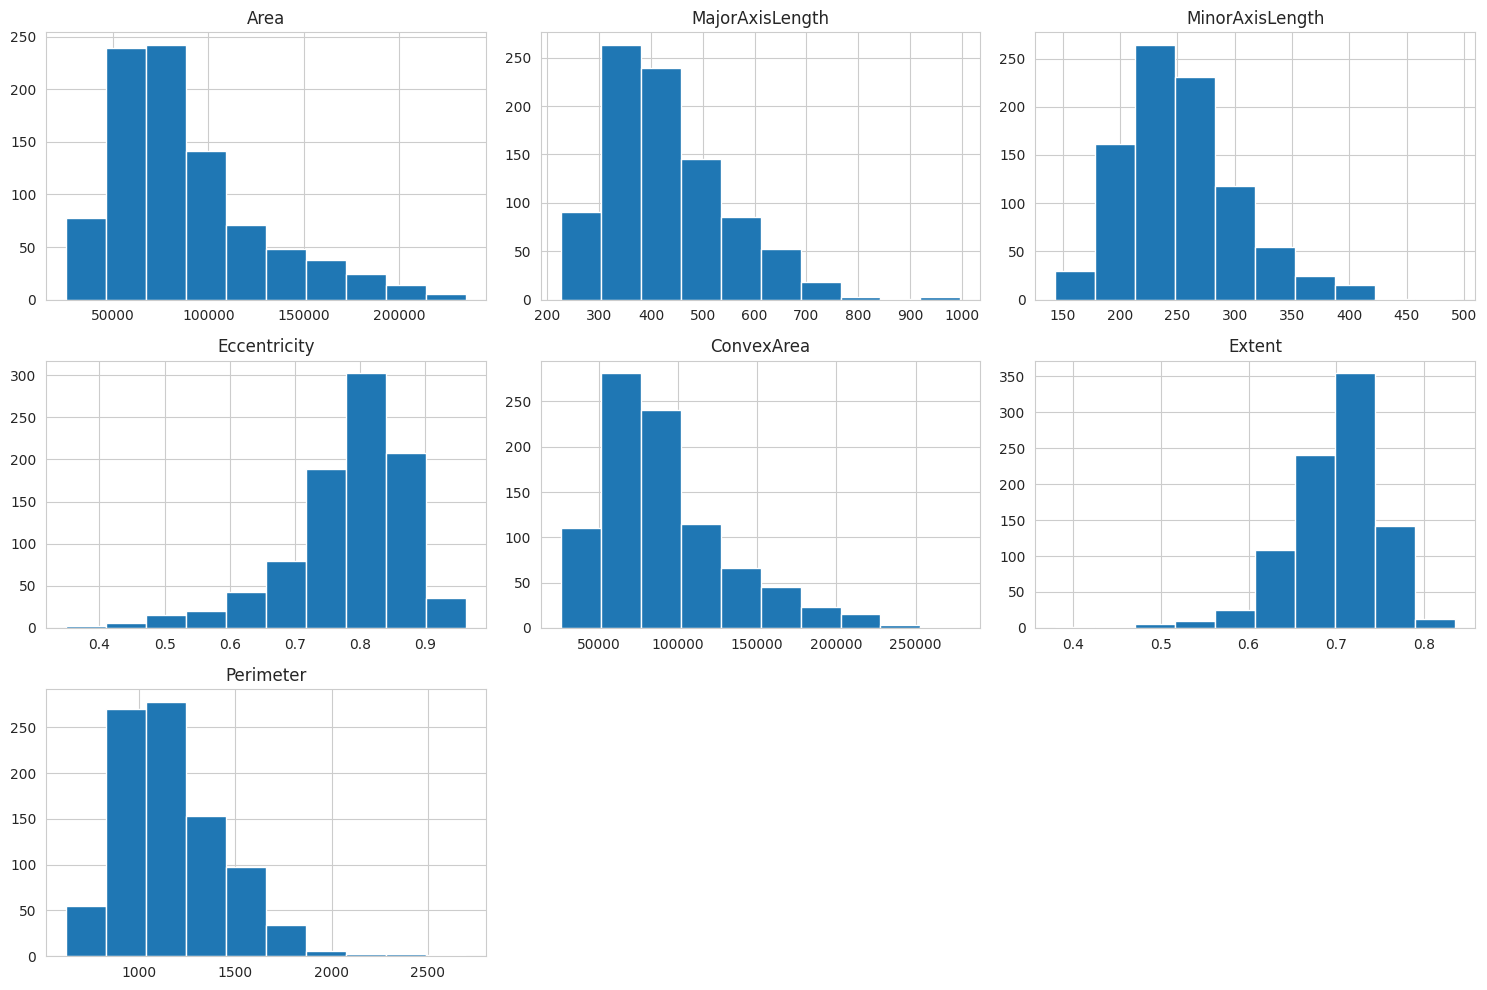

In [9]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

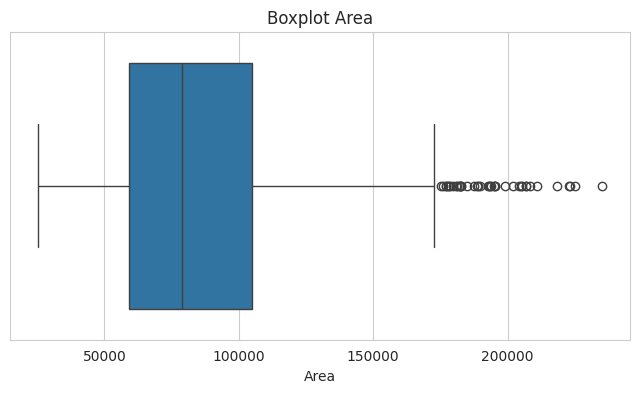

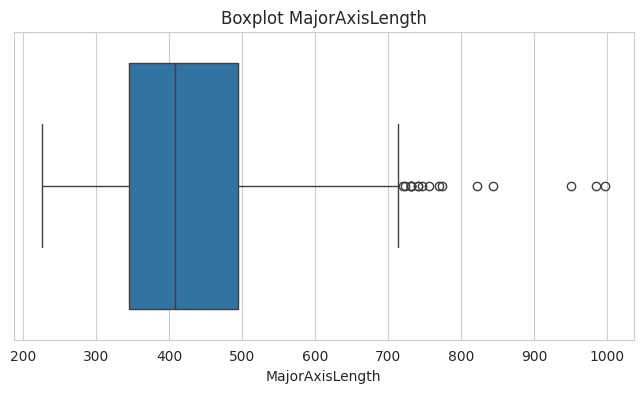

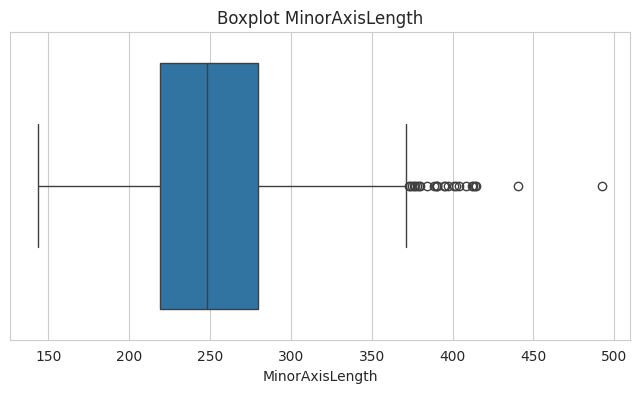

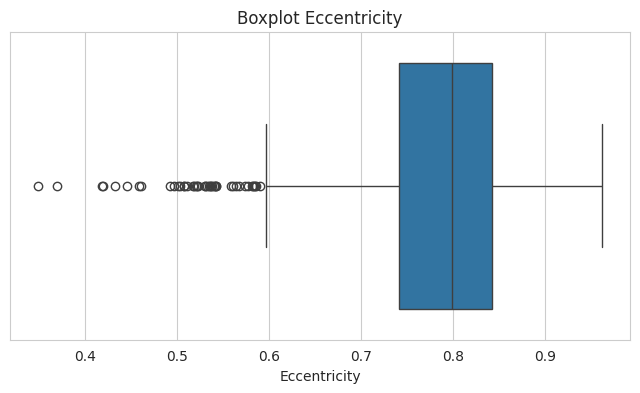

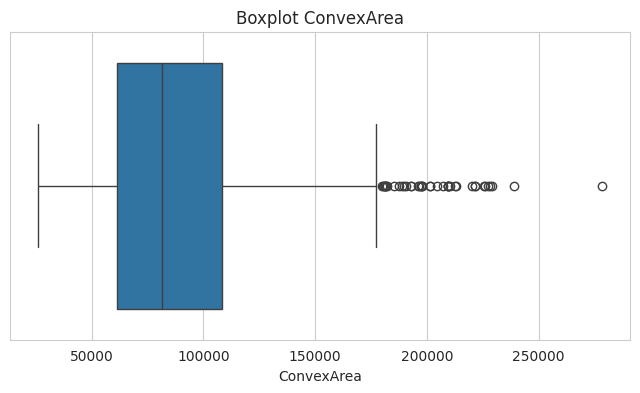

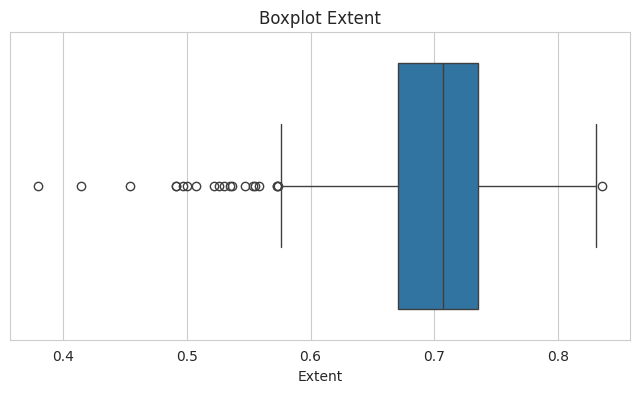

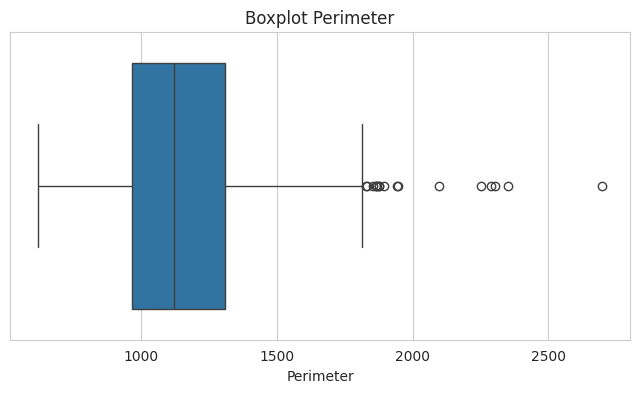

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

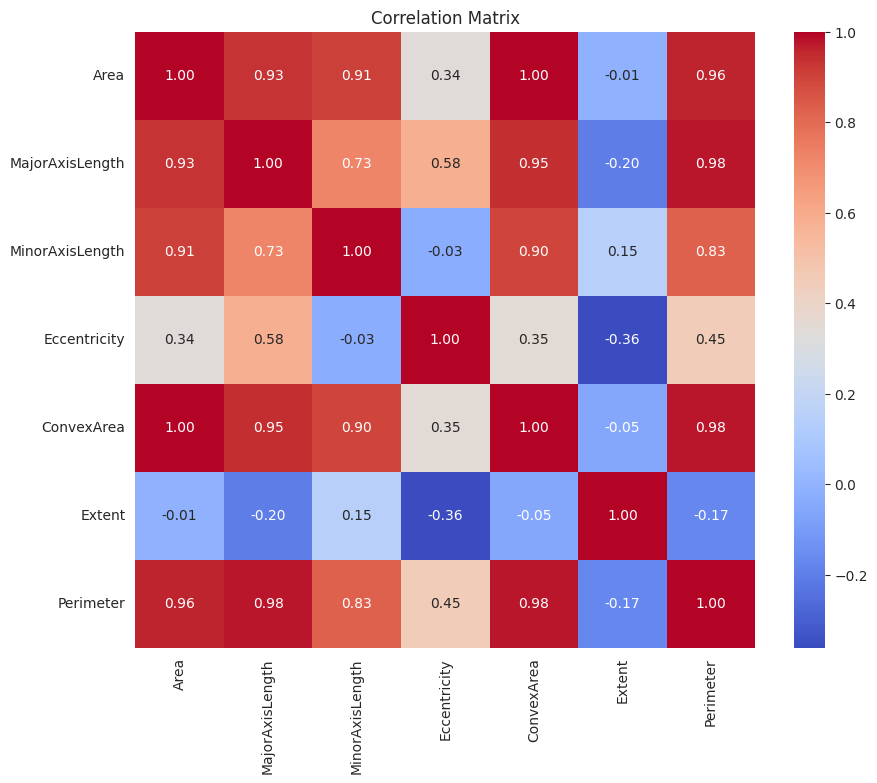

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

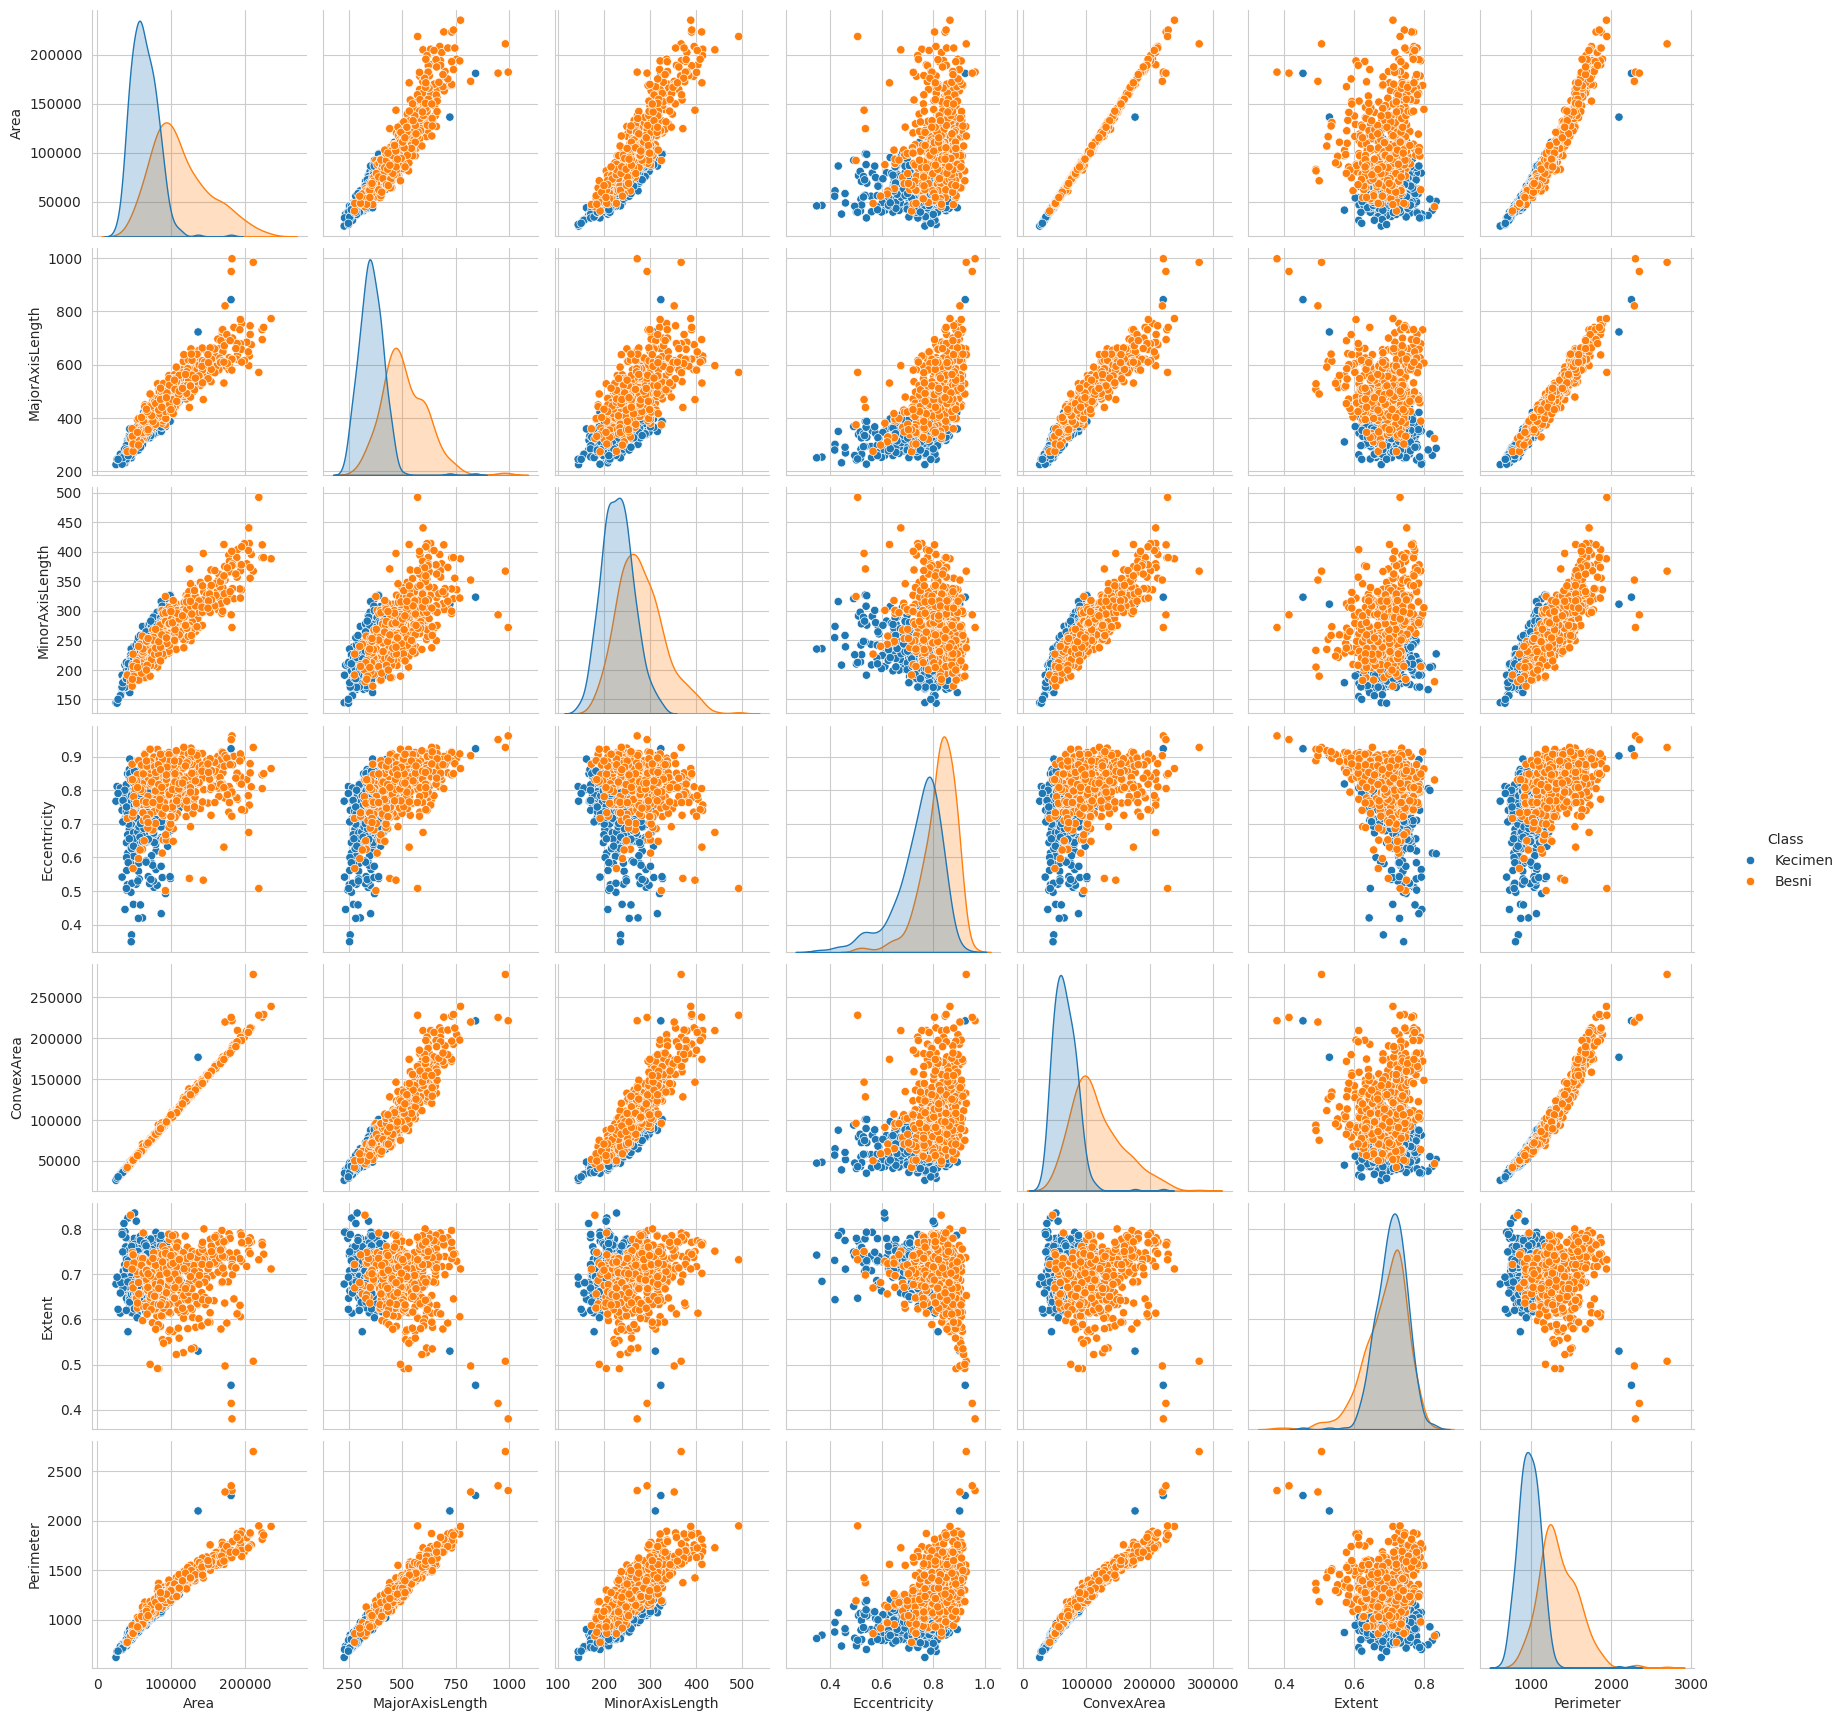

In [12]:
sns.pairplot(df, hue='Class')
plt.show()

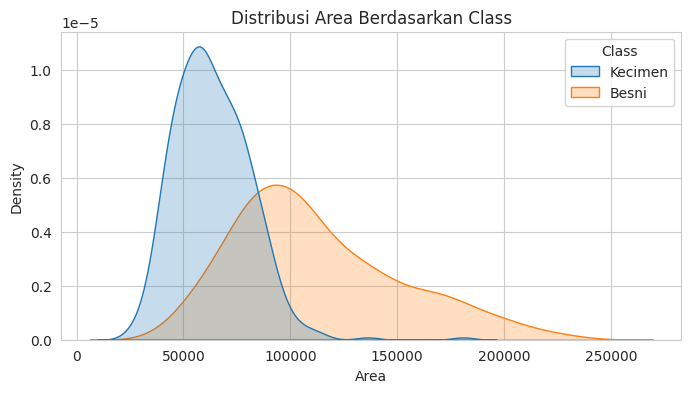

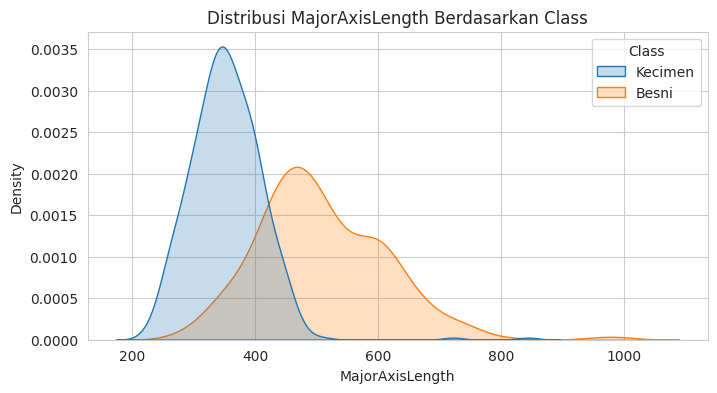

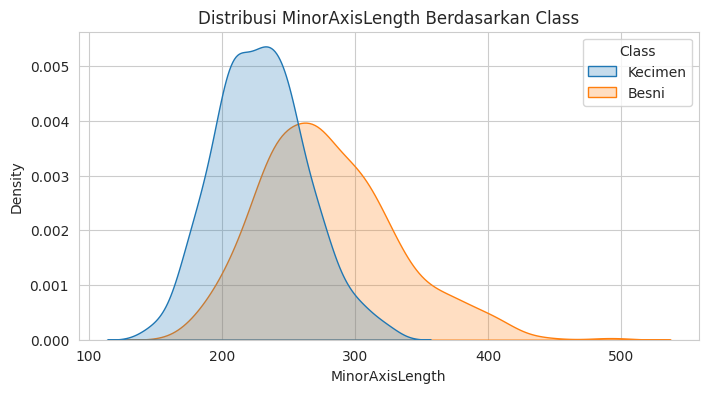

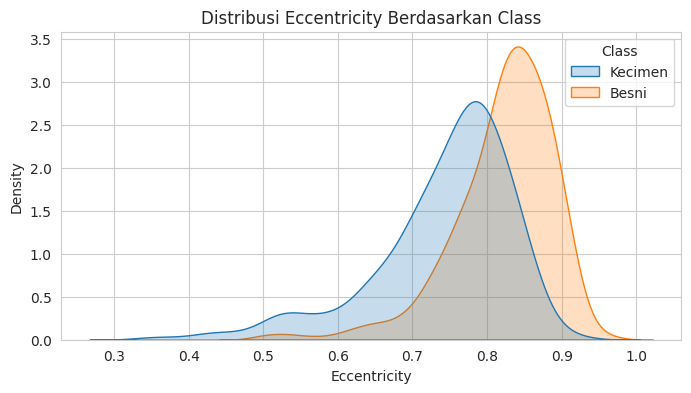

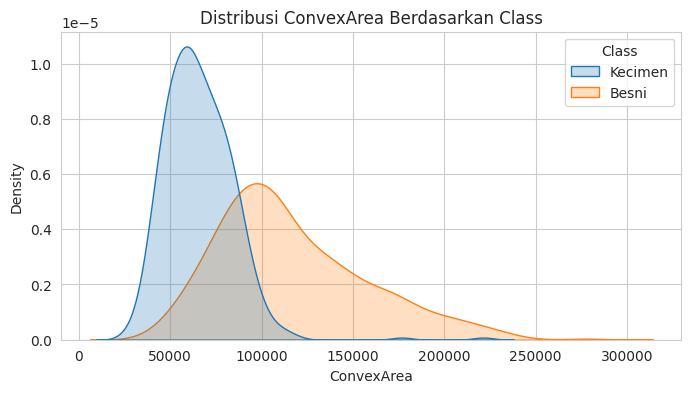

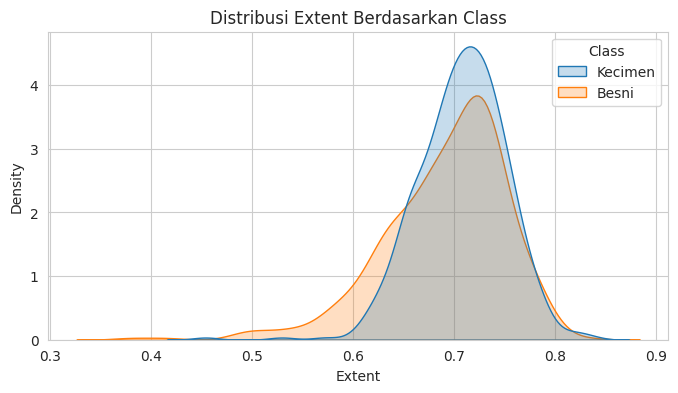

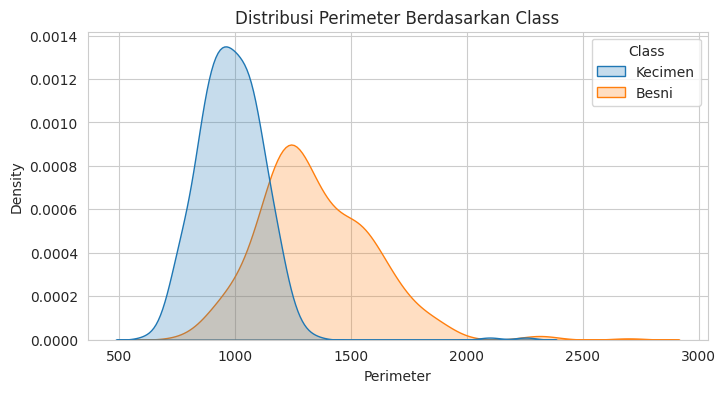

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    
    sns.kdeplot(data=df,
                x=col,
                hue='Class',
                fill=True)
    
    plt.title(f'Distribusi {col} Berdasarkan Class')
    plt.show()

# **5. Data Preprocessing**

In [14]:
le = LabelEncoder()

df['Class'] = le.fit_transform(df['Class'])

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,1
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,1
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,1
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,1
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,1


In [15]:
X = df.drop('Class', axis=1)
y = df['Class']

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
0,-0.007186,0.097577,-0.023958,0.423142,-0.015709,1.106743,0.066274
1,-0.324217,-0.209012,-0.229292,0.224476,-0.304248,-0.287777,-0.161252
2,0.078292,0.097758,0.236988,0.186239,0.062113,-1.158250,0.155945
3,-1.074286,-1.245051,-0.915273,-1.069623,-1.076165,0.001711,-1.175915
4,-0.215393,-0.678958,0.727354,-2.409827,-0.238623,1.745259,-0.338639


In [17]:
# Gabungkan kembali feature dan target
df_preprocessed = X_scaled.copy()

df_preprocessed['Class'] = y.values

# Simpan ke CSV
df_preprocessed.to_csv('raisin_preprocessed.csv', index=False)

print("Raisin_preprocessed.csv")

Raisin_preprocessed.csv


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X Train :", X_train.shape)
print("X Test :", X_test.shape)

X Train : (720, 7)
X Test : (180, 7)
